### Q1) Implement linear support vector classification on the given dataset and visualize it.

   Daily Time Spent on Site  Age  Area Income  Daily Internet Usage  \
0                     68.95   35     61833.90                256.09   
1                     80.23   31     68441.85                193.77   
2                     69.47   26     59785.94                236.50   
3                     74.15   29     54806.18                245.89   
4                     68.37   35     73889.99                225.58   

                           Ad Topic Line            City  Male     Country  \
0     Cloned 5thgeneration orchestration     Wrightburgh     0     Tunisia   
1     Monitored national standardization       West Jodi     1       Nauru   
2       Organic bottom-line service-desk        Davidton     0  San Marino   
3  Triple-buffered reciprocal time-frame  West Terrifurt     1       Italy   
4          Robust logistical utilization    South Manuel     0     Iceland   

             Timestamp  Clicked on Ad  
0  2016-03-27 00:53:11              0  
1  2016-04-04 01:39:02  

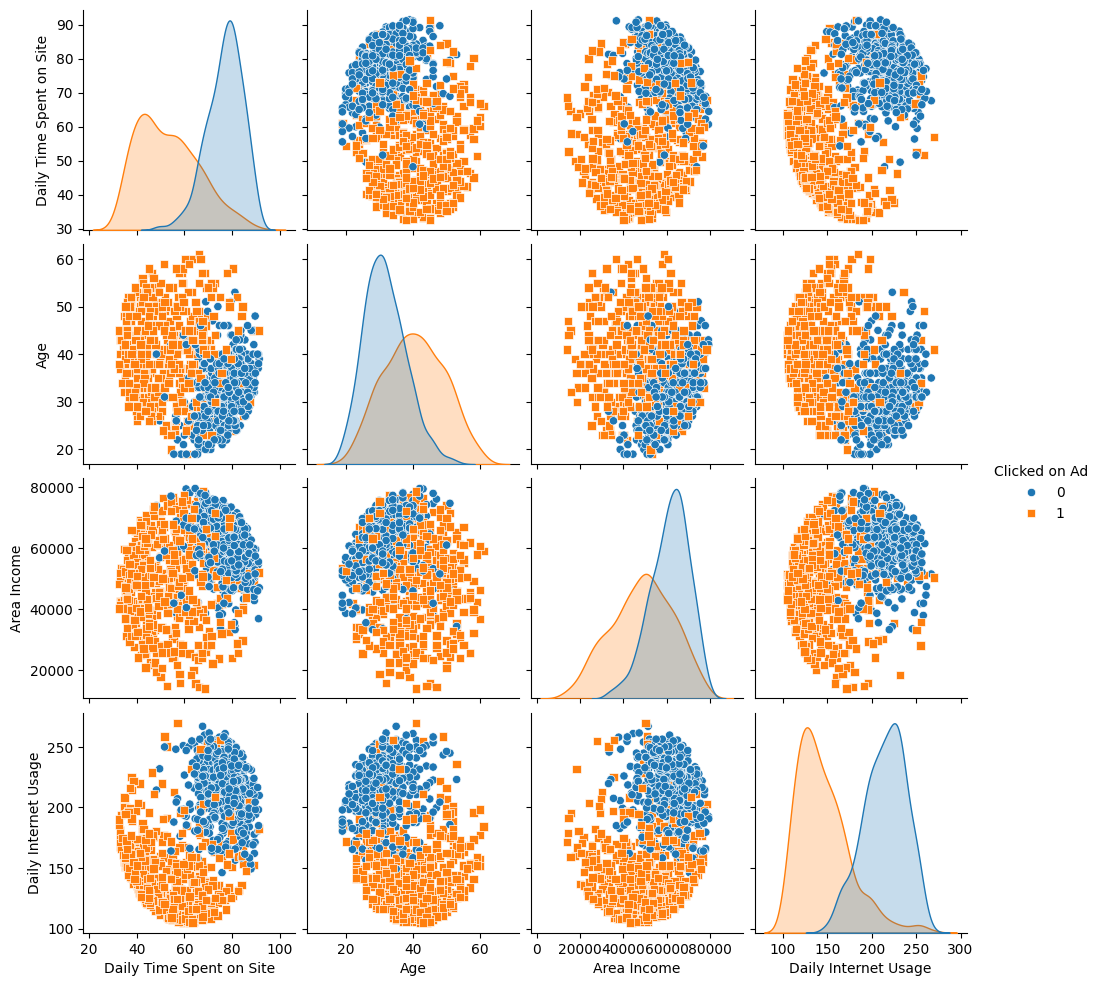

C:\Users\PMLS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


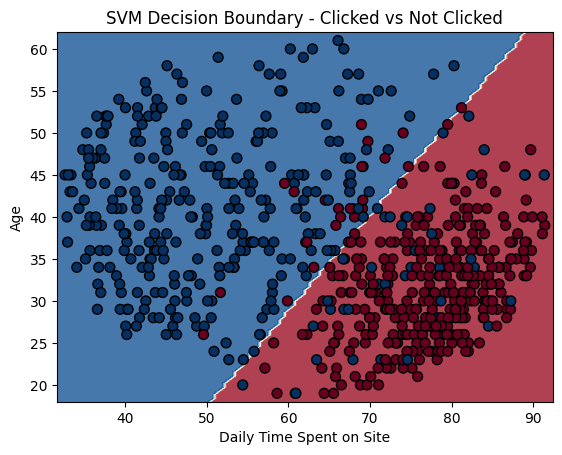

In [1]:
# Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
import numpy as np

# Load the dataset
df = pd.read_csv('advertising(1).csv')

# Show the first few rows of the dataset
print(df.head())

# Drop the 'Timestamp' column as it is irrelevant for modeling
df = df.drop('Timestamp', axis=1)

# Label encoding for 'Ad Topic Line' column
label_encoder = LabelEncoder()
df['Ad Topic Line'] = label_encoder.fit_transform(df['Ad Topic Line'])

# One-hot encode the 'City' and 'Country' columns
df = pd.get_dummies(df, columns=['City', 'Country'], drop_first=True)

# Define features (X) and target (y)
X = df.drop('Clicked on Ad', axis=1)  # Features
y = df['Clicked on Ad']  # Target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize the data
scaler = StandardScaler()

# Create an SVM pipeline
svm_pipeline = Pipeline([
    ('scaler', scaler),
    ('svm', SVC(kernel='linear', random_state=42))  # SVM with linear kernel
])

# Train the SVM model
svm_pipeline.fit(X_train, y_train)

# Make predictions
y_pred = svm_pipeline.predict(X_test)

# Show the classification report
print(classification_report(y_test, y_pred))

# Visualize relationships using seaborn (focusing on relevant columns)
# Use a subset of columns for better visualization
sns.pairplot(df[['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Clicked on Ad']], 
             hue="Clicked on Ad", diag_kind="kde", markers=["o", "s"])
plt.show()

# Visualize the decision boundary
# We'll select two features to visualize the decision boundary
X_vis = X[['Daily Time Spent on Site', 'Age']]  # Select features for visualization
X_vis_train, X_vis_test, y_vis_train, y_vis_test = train_test_split(X_vis, y, test_size=0.3, random_state=42)

# Train the SVM with the selected features
svm_pipeline.fit(X_vis_train, y_vis_train)

# Create a grid of points to plot the decision boundaries
x_min, x_max = X_vis['Daily Time Spent on Site'].min() - 1, X_vis['Daily Time Spent on Site'].max() + 1
y_min, y_max = X_vis['Age'].min() - 1, X_vis['Age'].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
Z = svm_pipeline.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdBu)
plt.scatter(X_vis_train['Daily Time Spent on Site'], X_vis_train['Age'], c=y_vis_train, edgecolors='k', marker='o', cmap=plt.cm.RdBu, s=50)
plt.xlabel('Daily Time Spent on Site')
plt.ylabel('Age')
plt.title('SVM Decision Boundary - Clicked vs Not Clicked')
plt.show()


### Q2) For different degrees, use polynomial kernel, and RBF kernel on the same dataset and observe the performance of all implementations. 

SVM with Linear Kernel
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       146
           1       0.92      0.88      0.90       154

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300

SVM with Rbf Kernel
              precision    recall  f1-score   support

           0       0.85      0.95      0.90       146
           1       0.94      0.84      0.89       154

    accuracy                           0.89       300
   macro avg       0.90      0.89      0.89       300
weighted avg       0.90      0.89      0.89       300

SVM with Polynomial Kernel (degree=2)
              precision    recall  f1-score   support

           0       0.50      0.68      0.58       146
           1       0.54      0.35      0.43       154

    accuracy                           0.51       300
   macro avg       0.52      0.52      0.50    

C:\Users\PMLS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


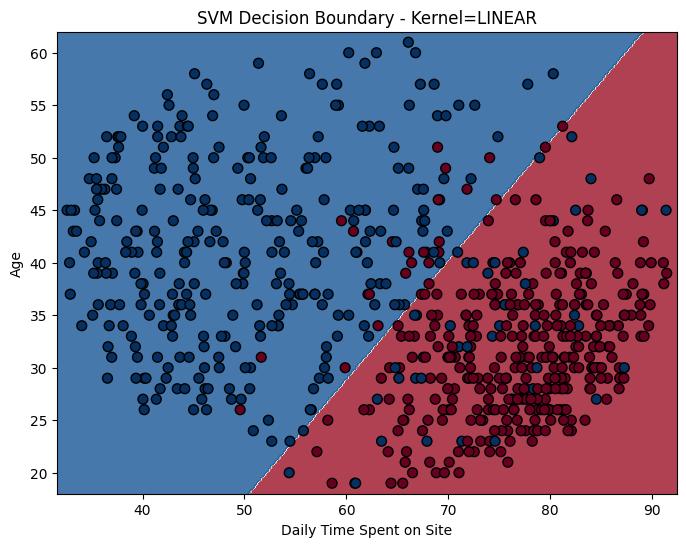

C:\Users\PMLS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


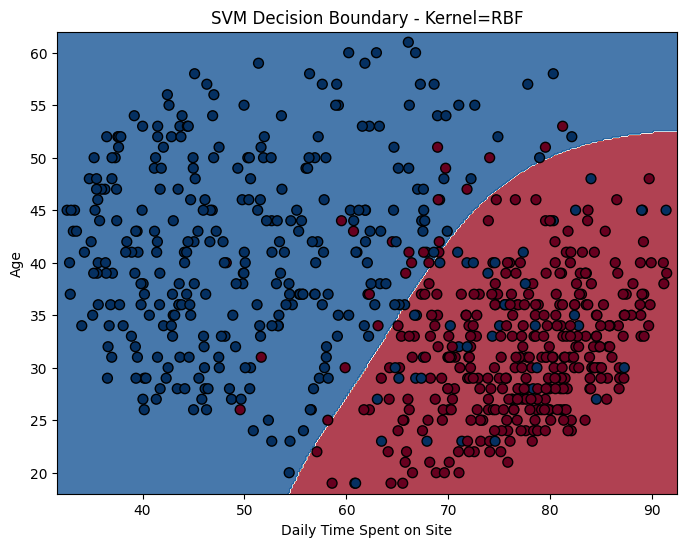

C:\Users\PMLS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


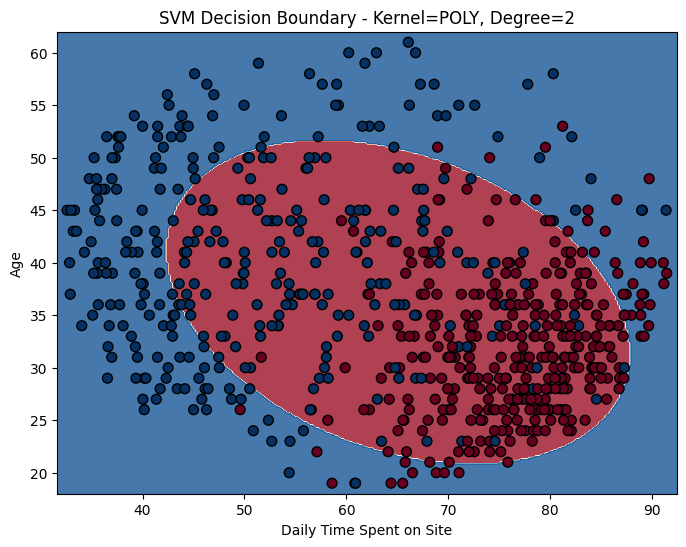

C:\Users\PMLS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


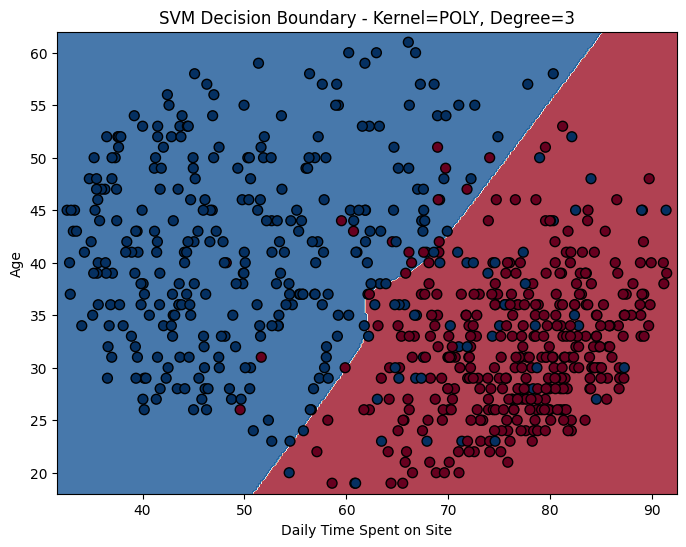

In [2]:
# Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
import numpy as np

# Load the dataset
df = pd.read_csv('advertising(1).csv')

# Drop irrelevant columns
df = df.drop('Timestamp', axis=1)

# Encode text features
label_encoder = LabelEncoder()
df['Ad Topic Line'] = label_encoder.fit_transform(df['Ad Topic Line'])

# One-hot encode categorical columns
df = pd.get_dummies(df, columns=['City', 'Country'], drop_first=True)

# Define features and target
X = df.drop('Clicked on Ad', axis=1)
y = df['Clicked on Ad']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Function to train and evaluate SVM
def train_and_evaluate_svm(X_train, X_test, y_train, y_test, kernel, degree=None):
    if kernel == 'poly':
        model = SVC(kernel=kernel, degree=degree, random_state=42)
        title = f'SVM with Polynomial Kernel (degree={degree})'
    else:
        model = SVC(kernel=kernel, random_state=42)
        title = f'SVM with {kernel.capitalize()} Kernel'

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    print("=" * 60)
    print(title)
    print(classification_report(y_test, y_pred))

    return pipeline

# Train and evaluate different kernels
svm_linear = train_and_evaluate_svm(X_train, X_test, y_train, y_test, kernel='linear')
svm_rbf = train_and_evaluate_svm(X_train, X_test, y_train, y_test, kernel='rbf')
svm_poly2 = train_and_evaluate_svm(X_train, X_test, y_train, y_test, kernel='poly', degree=2)
svm_poly3 = train_and_evaluate_svm(X_train, X_test, y_train, y_test, kernel='poly', degree=3)

# Optional: Visualize decision boundary using 2 features
# Select 2 features for visualization
X_vis = df[['Daily Time Spent on Site', 'Age']]
y_vis = df['Clicked on Ad']
X_vis_train, X_vis_test, y_vis_train, y_vis_test = train_test_split(X_vis, y_vis, test_size=0.3, random_state=42)

# Function to plot decision boundary
def plot_decision_boundary(pipeline, X_train, y_train, title):
    x_min, x_max = X_train.iloc[:, 0].min() - 1, X_train.iloc[:, 0].max() + 1
    y_min, y_max = X_train.iloc[:, 1].min() - 1, X_train.iloc[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))

    Z = pipeline.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdBu)
    plt.scatter(X_train.iloc[:, 0], X_train.iloc[:, 1], c=y_train, edgecolors='k', cmap=plt.cm.RdBu, s=50)
    plt.xlabel('Daily Time Spent on Site')
    plt.ylabel('Age')
    plt.title(title)
    plt.show()

# Train and plot for each kernel with 2 features
kernels = [
    ('linear', None),
    ('rbf', None),
    ('poly', 2),
    ('poly', 3)
]

for kernel, degree in kernels:
    model = SVC(kernel=kernel, degree=degree) if kernel == 'poly' else SVC(kernel=kernel)
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', model)
    ])
    pipeline.fit(X_vis_train, y_vis_train)
    title = f"SVM Decision Boundary - Kernel={kernel.upper()}" + (f", Degree={degree}" if degree else "")
    plot_decision_boundary(pipeline, X_vis_train, y_vis_train, title)


### Q3) Adjust the regularization and gamma hyperparameters and observe the changes.

SVM (Linear, C=0.1, gamma=scale)
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       146
           1       0.92      0.88      0.90       154

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300

SVM (Linear, C=1.0, gamma=scale)
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       146
           1       0.92      0.88      0.90       154

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300

SVM (Linear, C=10.0, gamma=scale)
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       146
           1       0.92      0.88      0.90       154

    accuracy                           0.90       300
   macro avg       0.90     

C:\Users\PMLS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


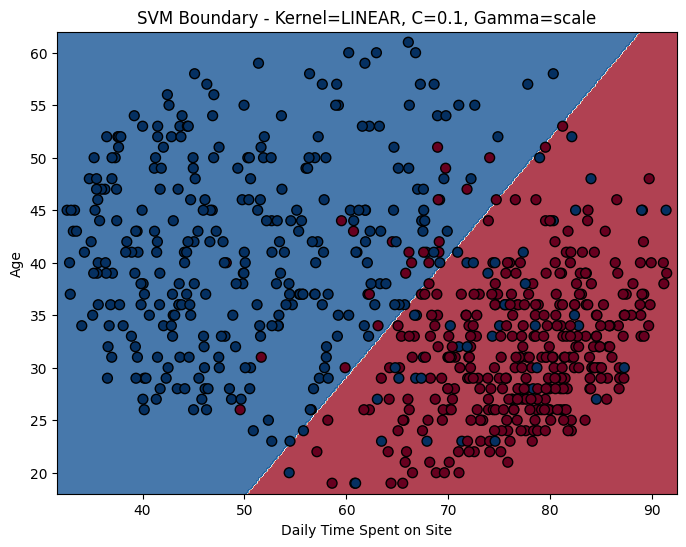

C:\Users\PMLS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


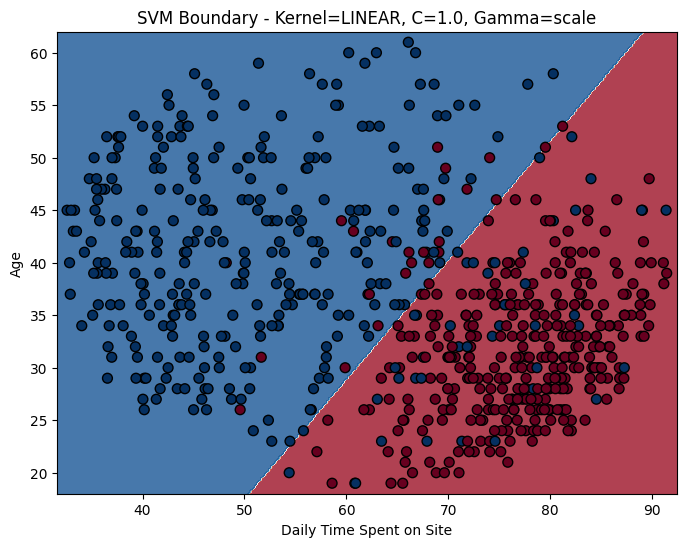

C:\Users\PMLS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


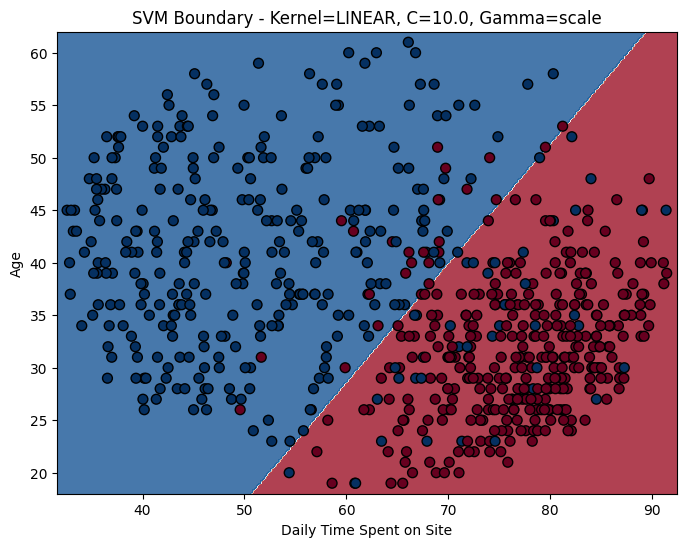

C:\Users\PMLS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


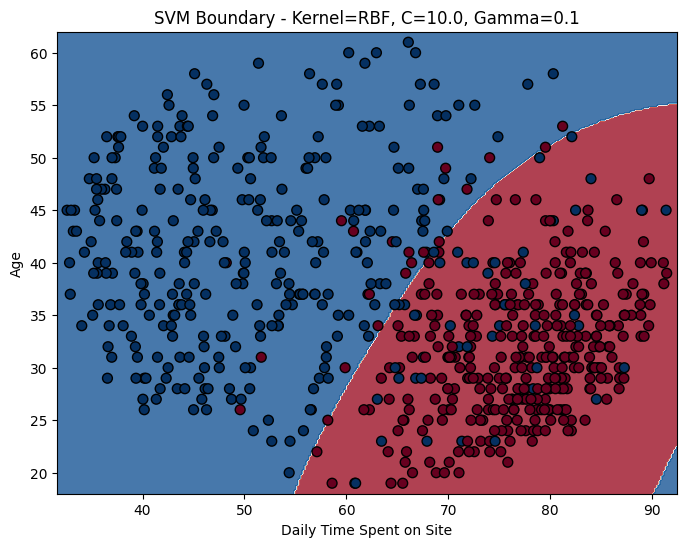

C:\Users\PMLS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


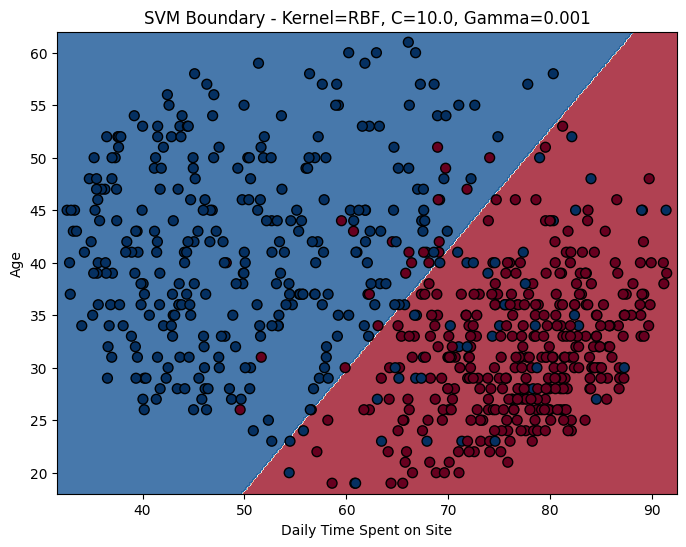

C:\Users\PMLS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


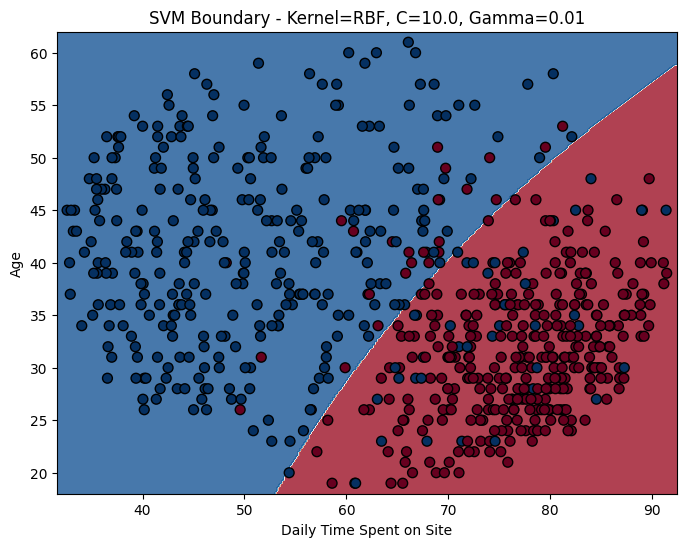

C:\Users\PMLS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


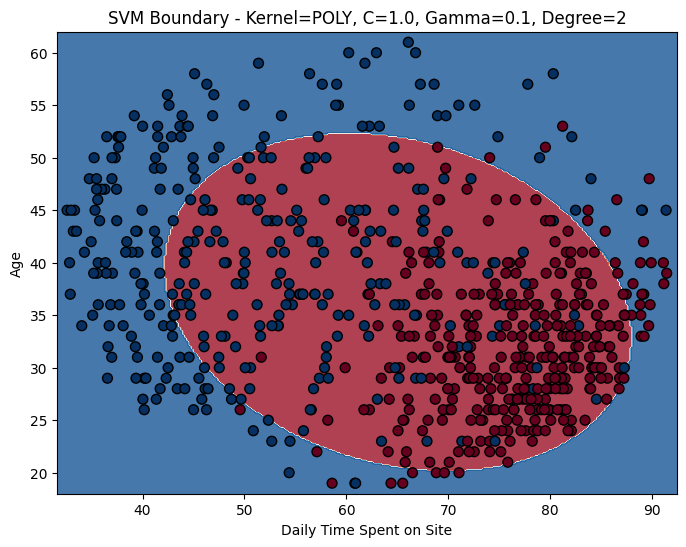

C:\Users\PMLS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


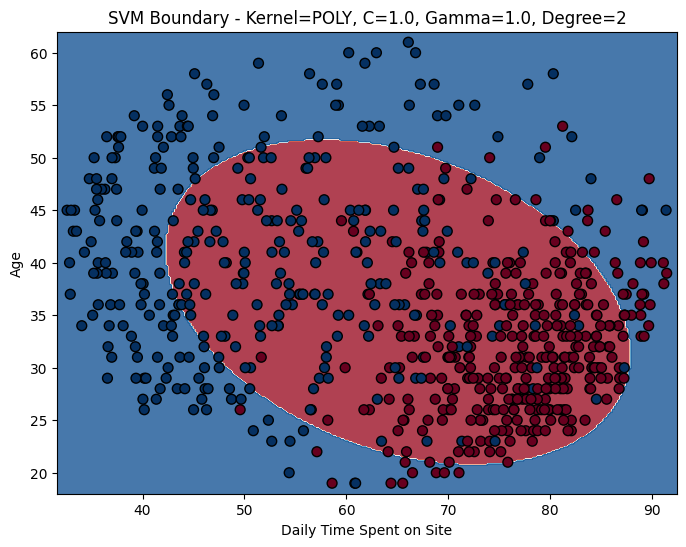

C:\Users\PMLS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


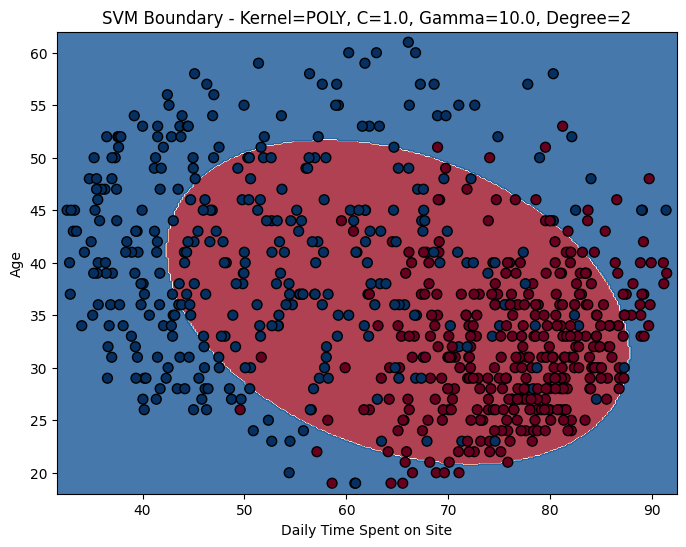

In [3]:
# Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
import numpy as np

# Load the dataset
df = pd.read_csv('advertising(1).csv')

# Drop irrelevant columns
df = df.drop('Timestamp', axis=1)

# Encode text features
label_encoder = LabelEncoder()
df['Ad Topic Line'] = label_encoder.fit_transform(df['Ad Topic Line'])

# One-hot encode categorical columns
df = pd.get_dummies(df, columns=['City', 'Country'], drop_first=True)

# Define features and target
X = df.drop('Clicked on Ad', axis=1)
y = df['Clicked on Ad']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Function to train and evaluate SVM
def train_and_evaluate_svm(X_train, X_test, y_train, y_test, kernel, C=1.0, gamma='scale', degree=None):
    if kernel == 'poly':
        model = SVC(kernel=kernel, degree=degree, C=C, gamma=gamma, random_state=42)
        title = f'SVM (Poly, degree={degree}, C={C}, gamma={gamma})'
    else:
        model = SVC(kernel=kernel, C=C, gamma=gamma, random_state=42)
        title = f'SVM ({kernel.capitalize()}, C={C}, gamma={gamma})'

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    print("=" * 70)
    print(title)
    print(classification_report(y_test, y_pred))

    return pipeline

# Define hyperparameter combinations
configs = [
    ('linear', 0.1, 'scale', None),
    ('linear', 1.0, 'scale', None),
    ('linear', 10.0, 'scale', None),
    ('rbf', 10.0, 0.1, None),
    ('rbf', 10.0, 0.001, None),
    ('rbf', 10.0, 0.01, None),
    ('poly', 1.0, 0.1, 2),
    ('poly', 1.0, 1.0, 2),
    ('poly', 1.0, 10.0, 2)
]

# Train and evaluate all configurations
for kernel, C, gamma, degree in configs:
    train_and_evaluate_svm(X_train, X_test, y_train, y_test, kernel, C, gamma, degree)

# Visualize decision boundary using 2 features
X_vis = df[['Daily Time Spent on Site', 'Age']]
y_vis = df['Clicked on Ad']
X_vis_train, X_vis_test, y_vis_train, y_vis_test = train_test_split(X_vis, y_vis, test_size=0.3, random_state=42)

def plot_decision_boundary(pipeline, X_train, y_train, title):
    x_min, x_max = X_train.iloc[:, 0].min() - 1, X_train.iloc[:, 0].max() + 1
    y_min, y_max = X_train.iloc[:, 1].min() - 1, X_train.iloc[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = pipeline.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdBu)
    plt.scatter(X_train.iloc[:, 0], X_train.iloc[:, 1], c=y_train, edgecolors='k', cmap=plt.cm.RdBu, s=50)
    plt.xlabel('Daily Time Spent on Site')
    plt.ylabel('Age')
    plt.title(title)
    plt.show()


for kernel, C, gamma, degree in configs:
    if kernel == 'poly':
        model = SVC(kernel=kernel, degree=degree, C=C, gamma=gamma)
    else:
        model = SVC(kernel=kernel, C=C, gamma=gamma)

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', model)
    ])
    pipeline.fit(X_vis_train, y_vis_train)
    title = f"SVM Boundary - Kernel={kernel.upper()}, C={C}, Gamma={gamma}" + (f", Degree={degree}" if degree else "")
    plot_decision_boundary(pipeline, X_vis_train, y_vis_train, title)


### Q4) Repeat the same for a dataset of your choice.

SVR (LINEAR), C=1.0, gamma=scale [ALL FEATURES]
Mean Squared Error: 1431223153.07
R² Score: -0.02


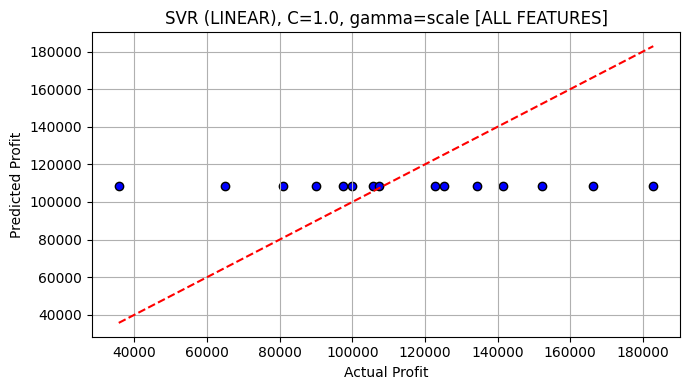

SVR (RBF), C=10.0, gamma=0.1 [ALL FEATURES]
Mean Squared Error: 1433030230.03
R² Score: -0.02


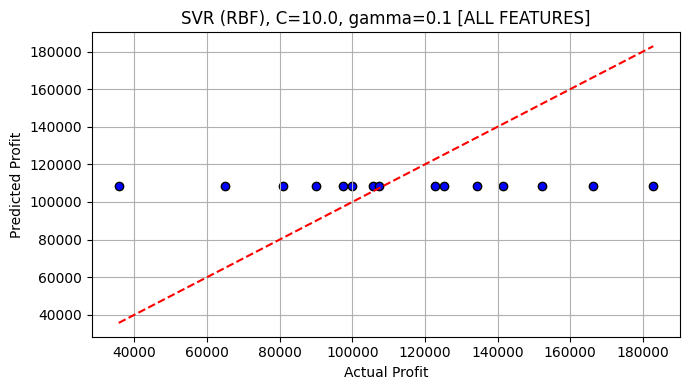

SVR (RBF), C=10.0, gamma=0.01 [ALL FEATURES]
Mean Squared Error: 1434211810.65
R² Score: -0.02


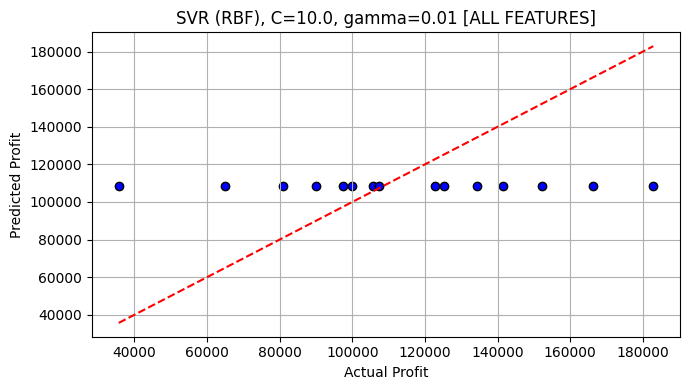

SVR (POLY), C=1.0, gamma=0.1, degree=2 [ALL FEATURES]
Mean Squared Error: 1434814678.71
R² Score: -0.02


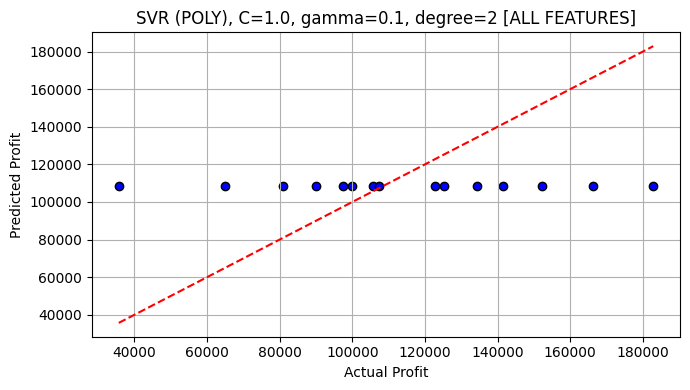

SVR (POLY), C=1.0, gamma=1.0, degree=2 [ALL FEATURES]
Mean Squared Error: 1434059311.71
R² Score: -0.02


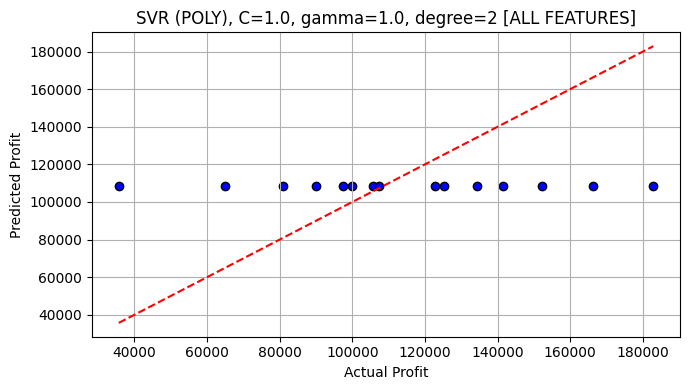

SVR (POLY), C=1.0, gamma=10.0, degree=2 [ALL FEATURES]
Mean Squared Error: 1443812833.54
R² Score: -0.03


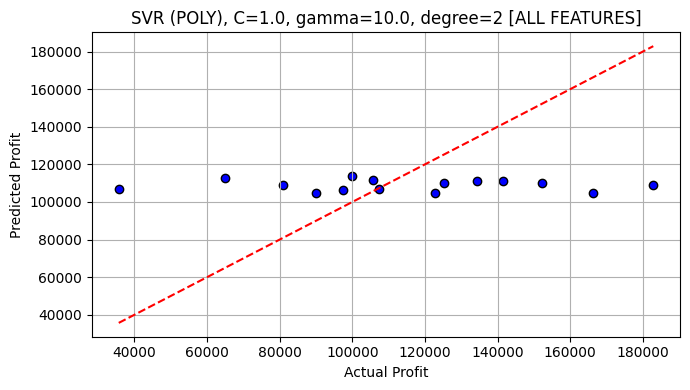

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load data
df = pd.read_csv('50_Startups.csv')

# Separate features and target
X_full = df.drop('Profit', axis=1)
y = df['Profit'].values

# OneHotEncode 'State'
column_transformer = ColumnTransformer(
    transformers=[('state', OneHotEncoder(), ['State'])],
    remainder='passthrough'
)

X_full_encoded = column_transformer.fit_transform(X_full)

# Split for evaluation
X_full_train, X_full_test, y_full_train, y_full_test = train_test_split(X_full_encoded, y, test_size=0.3, random_state=42)

# Define SVR training and evaluation function
def train_and_evaluate_svr(X_train, X_test, y_train, y_test, kernel, C=1.0, gamma='scale', degree=3, title_suffix=''):
    svr = SVR(kernel=kernel, C=C, gamma=gamma, degree=degree)
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svr', svr)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # Evaluation
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    title = f'SVR ({kernel.upper()}), C={C}, gamma={gamma}' + (f', degree={degree}' if kernel == 'poly' else '') + f' {title_suffix}'

    print("=" * 80)
    print(title)
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"R² Score: {r2:.2f}")

    # Plot
    plt.figure(figsize=(7, 4))
    plt.scatter(y_test, y_pred, color='blue', edgecolor='k')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('Actual Profit')
    plt.ylabel('Predicted Profit')
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Configurations
configs = [
    ('linear', 1.0, 'scale', 3),
    ('rbf', 10.0, 0.1, 3),
    ('rbf', 10.0, 0.01, 3),
    ('poly', 1.0, 0.1, 2),
    ('poly', 1.0, 1.0, 2),
    ('poly', 1.0, 10.0, 2)
]

# ➤ Train SVR on ALL FEATURES
for kernel, C, gamma, degree in configs:
    train_and_evaluate_svr(X_full_train, X_full_test, y_full_train, y_full_test,
                           kernel, C, gamma, degree, title_suffix='[ALL FEATURES]')
